### Necessary Imports

In [1]:
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

#### Now we'll use the stored rcparams.txt file to format our figure

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [5]:
well_fit_train = np.load('files/losses/well_fit/asassn_clump_train_loss8-16-32.npy')
well_fit_validation = np.load('files/losses/well_fit/asassn_clump_val_loss8-16-32.npy')

over_fit_train = np.load('files/losses/over_fit/asassn_clump_train_loss_64-128-256.npy')
overfit_validation = np.load('files/losses/over_fit/asassn_clump_val_loss_64-128-256.npy')


training_wellfit = pd.DataFrame(data=np.float64(well_fit_train[1:]), index=np.arange(len(well_fit_train)-1), columns=['loss'])
validation_wellfit = pd.DataFrame(data=np.float64(well_fit_validation[1:]), index=np.arange(len(well_fit_validation)-1), columns=['loss'])

training_overfit = pd.DataFrame(data=np.float64(over_fit_train[1:]), index=np.arange(len(over_fit_train)-1), columns=['loss'])
validation_overfit = pd.DataFrame(data=np.float64(overfit_validation[1:]), index=np.arange(len(overfit_validation)-1), columns=['loss'])

In [ ]:
def learning_curve_plot(dftrain, dfval):
    """ Plotter for the learning curves

    Args:
        dftrain (pandas.DataFrame): training fit as a DataFrame
        minimum (boolean): validation fit as a DataFrame
    Returns:
        None
        
    """
    
    epoch = 1 + np.arange(len(dftrain))
    fig, ax = plt.subplots(1, 1, figsize=(10, 5), layout='constrained')
    ax.plot(epoch, dftrain['loss'].to_list(), rasterized=True, linewidth=5)
    ax.plot(epoch, dfval['loss'].to_list(), alpha=0.5, rasterized=True, linewidth=5)
    ax.set_xlabel("Epoch", weight='bold')
    ax.set_ylabel("Loss", weight='bold')
    plt.legend(["Training", "Validation"])
    plt.show()

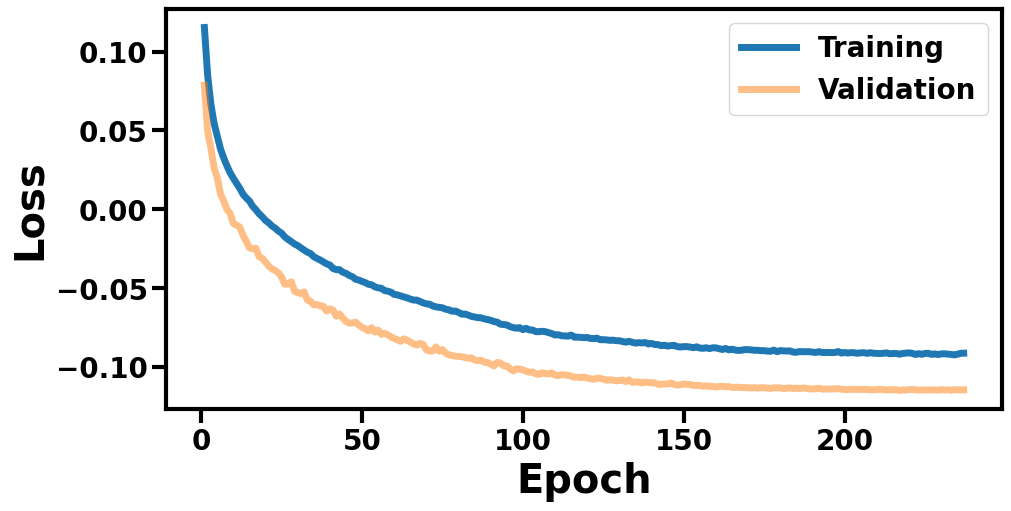

In [12]:
learning_curve_plot(training_wellfit, validation_wellfit)

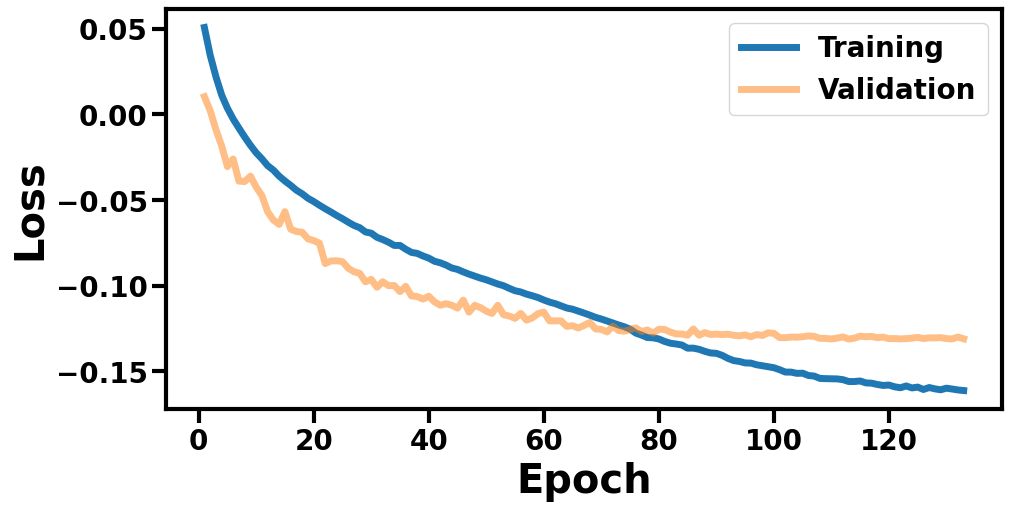

In [13]:
learning_curve_plot(training_overfit, validation_overfit)